# Projet AMMC

# Agent Scrapping

In [4]:
!pip install schedule


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import requests
from bs4 import BeautifulSoup
import os
import csv
from datetime import datetime
import time
import re
import schedule
from typing import Tuple, Optional, Dict
import concurrent.futures

# =========================================================
# GESTION SSL
# =========================================================

from requests.packages.urllib3.exceptions import InsecureRequestWarning

requests.packages.urllib3.disable_warnings(
    InsecureRequestWarning
)

# =========================================================
# CONFIGURATION
# =========================================================

BASE_URL = "https://www.ammc.ma"

DOCUMENTS_BASE_URL = (
    f"{BASE_URL}/fr/liste-etats-financiers-emetteurs"
)

DOWNLOAD_DIR = "ammc_pdf_filtre"

METADATA_FILE = "aa"

MAX_PAGES = 500

MIN_DOCUMENTS_PER_PAGE = 3

MAX_WORKERS = 5

# =========================================================
# ENTREPRISES CIBLES
# =========================================================

TARGET_COMPANIES = [
    "AFRIQUIA GAZ",
    "ADDOHA",
    "MAROC TELECOM",
    "ATTIJARIWAFA",
    "COSUMAR"
]

# =========================================================
# CREATION DOSSIER
# =========================================================

if not os.path.exists(DOWNLOAD_DIR):

    os.makedirs(DOWNLOAD_DIR)

# =========================================================
# HEADERS
# =========================================================

HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 '
        '(Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 '
        '(KHTML, like Gecko) '
        'Chrome/91.0.4472.124 Safari/537.36'
    )
}

# =========================================================
# VERIFIER ENTREPRISE CIBLE
# =========================================================

def est_entreprise_cible(
    nom_emetteur: str
) -> bool:

    nom_upper = nom_emetteur.upper()

    for cible in TARGET_COMPANIES:

        if cible in nom_upper:

            return True

    return False

# =========================================================
# TELECHARGEMENT PDF
# =========================================================

def telecharger_pdf(
    url_document: str,
    nom_fichier: str
) -> Tuple[bool, Optional[str]]:

    chemin_fichier = os.path.join(
        DOWNLOAD_DIR,
        nom_fichier
    )

    # Eviter doublons

    if os.path.exists(chemin_fichier):

        print(f"⚠️ Déjà téléchargé : {nom_fichier}")

        return True, chemin_fichier

    try:

        reponse = requests.get(
            url_document,
            headers=HEADERS,
            stream=True,
            timeout=60,
            verify=False
        )

        reponse.raise_for_status()

        with open(chemin_fichier, 'wb') as f:

            for chunk in reponse.iter_content(
                chunk_size=8192
            ):

                f.write(chunk)

        print(f" PDF téléchargé : {nom_fichier}")

        return True, chemin_fichier

    except Exception as e:

        return False, f"Erreur: {str(e)}"

# =========================================================
# TYPE DOCUMENT
# =========================================================

def determiner_type_document(
    url_fiche: str
) -> str:

    url_lower = url_fiche.lower()

    if re.search(
        r'semestriel|s1|s2|juin|rfs|semest',
        url_lower
    ):

        return "Semestriel"

    elif re.search(
        r'annuel|ra|rapport_annuel|decembre',
        url_lower
    ):

        return "Annuel"

    return "Autre"

# =========================================================
# TRAITEMENT DOCUMENT
# =========================================================

def traiter_un_document(
    info_doc: Dict
) -> Optional[list]:

    nom_emetteur = info_doc['nom']

    url_fiche = info_doc['url_fiche']

    annee_fiscale = info_doc['annee']

    type_doc = determiner_type_document(
        url_fiche
    )

    try:

        print(f"🔍 Analyse : {nom_emetteur}")

        # ==========================================
        # OUVRIR PAGE FICHE
        # ==========================================

        fiche_reponse = requests.get(
            url_fiche,
            headers=HEADERS,
            timeout=30,
            verify=False
        )

        fiche_reponse.raise_for_status()

        fiche_soup = BeautifulSoup(
            fiche_reponse.text,
            'html.parser'
        )

        # ==========================================
        # CHERCHER PDF
        # ==========================================

        lien_pdf_tag = fiche_soup.select_one(
            'a[href$=".pdf"]'
        )

        if not lien_pdf_tag:

            lien_pdf_tag = fiche_soup.select_one(
                'a[href*=".pdf"]'
            )

        if not lien_pdf_tag:

            print("❌ Aucun PDF trouvé")

            return None

        url_partielle = lien_pdf_tag['href']

        url_pdf_final = (
            url_partielle
            if url_partielle.startswith('http')
            else BASE_URL + url_partielle
        )

        # ==========================================
        # NOM FICHIER
        # ==========================================

        nom_base = (
            f"{nom_emetteur}_"
            f"{type_doc}_"
            f"{annee_fiscale}"
        )

        nom_clean = re.sub(
            r'[\\/:*?"<>|()]',
            '',
            nom_base
        ).replace(' ', '_')

        nom_fichier = f"{nom_clean}.pdf"

        # ==========================================
        # TELECHARGER PDF
        # ==========================================

        succes, chemin_ou_erreur = telecharger_pdf(
            url_pdf_final,
            nom_fichier
        )

        if succes:

            print(
                f"✅ [OK] "
                f"{nom_emetteur} "
                f"({annee_fiscale})"
            )

            return [
                nom_emetteur,
                annee_fiscale,
                type_doc
            ]

        else:

            print(
                f"❌ [Erreur DL] "
                f"{nom_emetteur}: "
                f"{chemin_ou_erreur}"
            )

            return None

    except Exception as e:

        print(
            f"❌ [Erreur Process] "
            f"{nom_emetteur}: {e}"
        )

        return None

# =========================================================
# SCRAPER PRINCIPAL
# =========================================================

def scraper_ammc_optimise():

    print(
        f"\n🚀 Démarrage scraping "
        f"sur {len(TARGET_COMPANIES)} entreprises"
    )

    # ==========================================
    # INITIALISATION CSV
    # ==========================================

    with open(
        METADATA_FILE,
        'w',
        newline='',
        encoding='utf-8'
    ) as f:

        writer = csv.writer(f)

        writer.writerow([
            'Emetteur',
            'Annee',
            'Type'
        ])

    total_docs = 0

    # ==========================================
    # MULTI THREADING
    # ==========================================

    with concurrent.futures.ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:

        for page_num in range(MAX_PAGES):

            current_url = (
                f"{DOCUMENTS_BASE_URL}"
                f"?page={page_num}"
            )

            if page_num % 5 == 0:

                print(
                    f"\n📄 Analyse Page {page_num}"
                )

            try:

                resp = requests.get(
                    current_url,
                    headers=HEADERS,
                    timeout=20,
                    verify=False
                )

                if resp.status_code != 200:

                    break

                soup = BeautifulSoup(
                    resp.text,
                    'html.parser'
                )

                rows = soup.select('table tr')

                rows_data = [
                    r for r in rows
                    if r.select('td')
                ]

                # ==================================
                # FIN PAGINATION
                # ==================================

                if (
                    len(rows_data)
                    < MIN_DOCUMENTS_PER_PAGE
                    and page_num > 0
                ):

                    print(
                        "🛑 Fin pagination détectée"
                    )

                    break

                tasks_data = []

                # ==================================
                # EXTRACTION DOCUMENTS
                # ==================================

                for row in rows_data:

                    cols = row.select('td')

                    if not cols:

                        continue

                    nom = cols[0].text.strip()

                    if not nom:

                        nom = cols[1].text.strip()

                    # ==============================
                    # FILTRE ENTREPRISES
                    # ==============================

                    if not est_entreprise_cible(nom):

                        continue

                    link_tag = row.select_one('a')

                    if not link_tag:

                        for c in cols:

                            if c.find('a'):

                                link_tag = c.find('a')

                                break

                    if (
                        link_tag
                        and link_tag.get('href')
                    ):

                        href = link_tag['href']

                        full_url = (
                            href
                            if href.startswith('http')
                            else BASE_URL + href
                        )

                        match_annee = re.search(
                            r'(\d{4})',
                            full_url
                        )

                        annee = (
                            match_annee.group(1)
                            if match_annee
                            else "Inconnue"
                        )

                        tasks_data.append({
                            'nom': nom,
                            'url_fiche': full_url,
                            'annee': annee
                        })

                if not tasks_data:

                    continue

                print(
                    f"✅ {len(tasks_data)} "
                    f"documents trouvés"
                )

                # ==================================
                # EXECUTION PARALLELE
                # ==================================

                future_to_doc = {

                    executor.submit(
                        traiter_un_document,
                        d
                    ): d

                    for d in tasks_data
                }

                for future in concurrent.futures.as_completed(
                    future_to_doc
                ):

                    result = future.result()

                    if result:

                        with open(
                            METADATA_FILE,
                            'a',
                            newline='',
                            encoding='utf-8'
                        ) as f:

                            csv.writer(f).writerow(result)

                        total_docs += 1

            except Exception as e:

                print(
                    f"❌ Erreur page "
                    f"{page_num}: {e}"
                )

                continue

    print(
        f"\n TERMINE ! "
        f"{total_docs} documents téléchargés."
    )

# =========================================================
# MISE A JOUR PERIODIQUE
# =========================================================

def scheduled_scraping():

    print(
        "\n Mise à jour automatique..."
    )

    scraper_ammc_optimise()

# =========================================================
# EXECUTION TEST 3 FOIS
# =========================================================

if __name__ == "__main__":

    # Premier lancement
    scraper_ammc_optimise()

    # Relance automatique chaque 1 minute
    schedule.every(1).minutes.do(
        scheduled_scraping
    )

    print("\n Scheduler activé")

    # TEST : seulement 3 fois
    for i in range(3):

        print(
            f"\n Attente exécution "
            f"{i+1}/3 ..."
        )

        schedule.run_pending()

        time.sleep(60)

    print("\n FIN TEST SCHEDULER")


🚀 Démarrage scraping sur 5 entreprises

📄 Analyse Page 0
✅ 2 documents trouvés
🔍 Analyse : ATTIJARIWAFA BANK
🔍 Analyse : ADDOHA
⚠️ Déjà téléchargé : ATTIJARIWAFA_BANK_Autre_2025.pdf
✅ [OK] ATTIJARIWAFA BANK (2025)
⚠️ Déjà téléchargé : ADDOHA_Autre_2025.pdf
✅ [OK] ADDOHA (2025)
✅ 1 documents trouvés
🔍 Analyse : COSUMAR
⚠️ Déjà téléchargé : COSUMAR_Autre_2025.pdf
✅ [OK] COSUMAR (2025)

📄 Analyse Page 5
✅ 2 documents trouvés
🔍 Analyse : MAROC TELECOM
🔍 Analyse : AFRIQUIA GAZ
⚠️ Déjà téléchargé : AFRIQUIA_GAZ_Autre_2025.pdf
✅ [OK] AFRIQUIA GAZ (2025)
⚠️ Déjà téléchargé : MAROC_TELECOM_Autre_2025.pdf
✅ [OK] MAROC TELECOM (2025)
✅ 2 documents trouvés
🔍 Analyse : ATTIJARIWAFA BANK
🔍 Analyse : AFRIQUIA GAZ
⚠️ Déjà téléchargé : AFRIQUIA_GAZ_Semestriel_2025.pdf
✅ [OK] AFRIQUIA GAZ (2025)
⚠️ Déjà téléchargé : ATTIJARIWAFA_BANK_Semestriel_2025.pdf
✅ [OK] ATTIJARIWAFA BANK (2025)
✅ 1 documents trouvés
🔍 Analyse : ADDOHA
⚠️ Déjà téléchargé : ADDOHA_Semestriel_2025.pdf
✅ [OK] ADDOHA (2025)
✅ 1 docum

KeyboardInterrupt: 

# Agent Extractor

# CONFIGURATION WINDOWS

In [4]:
import pytesseract
import pandas as pd
from pdf2image import convert_from_path
import pdfplumber
import os

# --- CONFIGURATION WINDOWS MODIFIÉE ---

# 1. Chemin vers l'exécutable Tesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

# 2. Chemin vers le dossier bin de Poppler (Mis à jour selon votre dernier message)
PATH_POPPLER = r'C:\poppler-25.12.0\Library\bin'


# Petite vérification de sécurité pour vous aider
if not os.path.exists(pytesseract.pytesseract.tesseract_cmd):
    print(" ATTENTION : Tesseract n'est pas trouvé au chemin indiqué.")
if not os.path.exists(PATH_POPPLER):
    print(" ATTENTION : Le dossier Poppler n'est pas trouvé au chemin indiqué.")
else:
    print("Configuration terminée : Les outils sont prêts.")

Configuration terminée : Les outils sont prêts.


In [1]:
import os
import re
import json
import sqlite3
import logging
import warnings

# =========================================================
# SUPPRESSION DES WARNINGS PDFMINER
# =========================================================

logging.getLogger(
    "pdfminer"
).setLevel(logging.ERROR)

warnings.filterwarnings("ignore")

# =========================================================

import pandas as pd
import pdfplumber
import pytesseract

from datetime import datetime
from typing import Dict, Optional, List, Tuple
from pdf2image import convert_from_path

# =================================================================
# CONFIGURATION
# =================================================================

pytesseract.pytesseract.tesseract_cmd = '/usr/bin/tesseract'

OCR_AVAILABLE = os.path.exists('/usr/bin/tesseract')

INPUT_DIR = "ammc_pdf_filtre"

DB_NAME = "finance_maroc_pro.db"

CSV_SOURCE = "ammc_data_cibles.csv"

OUTPUT_JSON_DIR = "ammc_resultats_json"

YEAR_20XX_PATTERN = re.compile(
    r"\b(20[0-2][0-9])\b"
)

for d in [INPUT_DIR, OUTPUT_JSON_DIR]:

    if not os.path.exists(d):

        os.makedirs(d)

logging.basicConfig(level=logging.INFO)

# =================================================================
# 1. DATABASE MANAGER
# =================================================================

class DatabaseManager:

    def __init__(self, db_name):

        self.conn = sqlite3.connect(db_name)

        self.cursor = self.conn.cursor()

        self._init_schema()

    # =============================================================

    def _init_schema(self):

        self.cursor.execute('''
            CREATE TABLE IF NOT EXISTS financial_data (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                emetteur TEXT,
                annee INTEGER,
                type_doc TEXT,
                metrique TEXT,
                valeur_brute TEXT,
                valeur_normalisee REAL,
                unite_detectee TEXT,
                source_method TEXT,
                score_confiance REAL,
                date_extraction TEXT
            )
        ''')

        self.cursor.execute('''
            CREATE TABLE IF NOT EXISTS quality_logs (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                emetteur TEXT,
                annee INTEGER,
                statut TEXT,
                message TEXT,
                timestamp TEXT
            )
        ''')

        self.conn.commit()

    # =============================================================

    def save_record(self, record: dict):

        date_str = datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )

        self.cursor.execute('''
            INSERT INTO financial_data 
            (
                emetteur,
                annee,
                type_doc,
                metrique,
                valeur_brute,
                valeur_normalisee,
                unite_detectee,
                source_method,
                score_confiance,
                date_extraction
            )
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        ''', (
            record['emetteur'],
            record['annee'],
            record['type_doc'],
            record['metrique'],
            str(record['valeur_brute']),
            record['valeur_normalisee'],
            record['unite'],
            record['method'],
            record['confiance'],
            date_str
        ))

        self.conn.commit()

    # =============================================================

    def log_quality(
        self,
        emetteur,
        annee,
        statut,
        message
    ):

        date_str = datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )

        self.cursor.execute('''
            INSERT INTO quality_logs
            (
                emetteur,
                annee,
                statut,
                message,
                timestamp
            )
            VALUES (?, ?, ?, ?, ?)
        ''', (
            emetteur,
            annee,
            statut,
            message,
            date_str
        ))

        self.conn.commit()

# =================================================================
# 2. DATA CLEANER
# =================================================================

class DataCleaner:

    @staticmethod
    def detect_unit(
        text: str
    ) -> Tuple[str, float]:

        t = text.lower()

        if any(
            x in t
            for x in [
                "millions",
                "mdh",
                "m mad"
            ]
        ):

            return "MDH", 1_000_000.0

        if any(
            x in t
            for x in [
                "milliers",
                "kdh",
                "k mad"
            ]
        ):

            return "KDH", 1_000.0

        return "DH", 1.0

    # =============================================================

    @staticmethod
    def parse_number(
        val_str: str
    ) -> Optional[float]:

        if not val_str:

            return None

        clean = (
            str(val_str)
            .replace(' ', '')
            .replace('\xa0', '')
            .replace('\u202f', '')
        )

        is_neg = False

        if '(' in clean and ')' in clean:

            is_neg = True

        # =========================================================
        # GESTION VIRGULES / POINTS
        # =========================================================

        if ',' in clean and '.' in clean:

            clean = (
                clean.replace('.', '')
                .replace(',', '.')
                if clean.find('.') < clean.find(',')
                else clean.replace(',', '')
            )

        elif ',' in clean:

            clean = clean.replace(',', '.')

        clean = re.sub(
            r'[^\d.-]',
            '',
            clean
        )

        try:

            res = float(clean)

            return -res if is_neg else res

        except:

            return None

# =================================================================
# 3. VALIDATION ANNEE
# =================================================================

def annee_valide(annee) -> bool:

    if pd.isna(annee):

        return False

    annee_str = str(annee).strip()

    # Format obligatoire : 20xx

    if not re.fullmatch(
        r"20\d{2}",
        annee_str
    ):

        return False

    annee_int = int(annee_str)

    # Intervalle raisonnable

    if annee_int < 2000 or annee_int > 2030:

        return False

    return True

# =================================================================
# 4. AGENT EXTRACTOR
# =================================================================

class FinancialExtractor:

    def __init__(self, pdf_path):

        self.pdf_path = pdf_path

        self.cleaner = DataCleaner()

        self.rubriques = {

            "actif_total": [
                "total actif",
                "total de l'actif",
                "total general"
            ],

            "capitaux_propres": [
                "total capitaux propres",
                "situation nette",
                "total des capitaux propres"
            ],

            "endettement": [
                "dettes de financement",
                "emprunts",
                "dettes financieres"
            ],

            "resultat_net": [
                "resultat net",
                "benefice net",
                "rnpg",
                "resultat de l'exercice"
            ],

            "cash_flow": [
                "flux net de tresorerie",
                "caf",
                "capacite d'autofinancement"
            ],

            "dividendes": [
                "dividendes",
                "dividende par action"
            ]
        }

    # =============================================================

    def process(
        self,
        meta: dict
    ) -> List[dict]:

        method = "NATIVE"

        full_text = ""

        structured_results = []

        # =========================================================

        try:

            with pdfplumber.open(
                self.pdf_path
            ) as pdf:

                for page in pdf.pages[:25]:

                    # =========================================
                    # EXTRACTION TABLEAUX
                    # =========================================

                    tables = page.extract_tables()

                    for table in tables:

                        for row in table:

                            row_str = " ".join([
                                str(c)
                                for c in row
                                if c
                            ]).lower()

                            for (
                                metrique,
                                keywords
                            ) in self.rubriques.items():

                                if any(
                                    kw in row_str
                                    for kw in keywords
                                ):

                                    for cell in row:

                                        num = (
                                            self.cleaner
                                            .parse_number(cell)
                                        )

                                        if (
                                            num is not None
                                            and not (
                                                2000 <= num <= 2030
                                            )
                                        ):

                                            structured_results.append(
                                                (
                                                    metrique,
                                                    num
                                                )
                                            )

                                            break

                    full_text += (
                        page.extract_text()
                        or ""
                    )

        except Exception as e:

            print(f"Erreur PDF : {e}")

        # =========================================================
        # OCR SI TEXTE VIDE
        # =========================================================

        if (
            len(full_text.strip()) < 150
            and OCR_AVAILABLE
        ):

            method = "OCR"

            try:

                images = convert_from_path(
                    self.pdf_path,
                    dpi=150,
                    last_page=5
                )

                full_text = "\n".join([

                    pytesseract.image_to_string(
                        img,
                        lang='fra'
                    )

                    for img in images

                ])

            except Exception as e:

                print(f"OCR Error : {e}")

        # =========================================================
        # DETECTION UNITE
        # =========================================================

        unit, factor = (
            self.cleaner.detect_unit(
                full_text
            )
        )

        final_data = []

        seen = set()

        # =========================================================
        # RESULTATS FINAUX
        # =========================================================

        for metrique, val in structured_results:

            if metrique in seen:

                continue

            final_data.append({

                **meta,

                'metrique': metrique,

                'valeur_brute': val,

                'valeur_normalisee': val * factor,

                'unite': unit,

                'method': method,

                'confiance': 0.9
            })

            seen.add(metrique)

        return final_data

# =================================================================
# 5. ORCHESTRATEUR
# =================================================================

def run_extraction_job():

    print(
        "\n Démarrage "
        "Agent Extractor AMMC..."
    )

    db = DatabaseManager(DB_NAME)

    df = pd.read_csv(CSV_SOURCE)

    fichiers_reels = (
        os.listdir(INPUT_DIR)
        if os.path.exists(INPUT_DIR)
        else []
    )

    processed_count = 0

    # =============================================================

    for _, row in df.iterrows():

        annee_val = row['Annee']

        # =========================================================
        # FILTRE ANNEES INVALIDES
        # =========================================================

        if not annee_valide(annee_val):

            print(
                f" Année ignorée : "
                f"{annee_val}"
            )

            db.log_quality(
                row['Emetteur'],
                0,
                "INVALID_YEAR",
                f"Année invalide : {annee_val}"
            )

            continue

        annee_val = str(annee_val)

        # =========================================================
        # RECHERCHE PDF
        # =========================================================

        target_file = None

        for f in fichiers_reels:

            if (
                annee_val in f
                and row['Emetteur'][:5]
                .upper() in f.upper()
            ):

                target_file = f

                break

        # =========================================================

        if target_file:

            pdf_path = os.path.join(
                INPUT_DIR,
                target_file
            )

            print(
                f" Extraction : "
                f"{target_file}"
            )

            extractor = FinancialExtractor(
                pdf_path
            )

            meta = {

                'emetteur': row['Emetteur'],

                'annee': int(annee_val),

                'type_doc': row['Type']
            }

            results = extractor.process(meta)

            # =====================================================
            # STOCKAGE
            # =====================================================

            if results:

                for res in results:

                    db.save_record(res)

                # =================================================
                # JSON
                # =================================================

                json_filename = (
                    target_file
                    .replace(".pdf", ".json")
                )

                with open(
                    os.path.join(
                        OUTPUT_JSON_DIR,
                        json_filename
                    ),
                    "w",
                    encoding="utf-8"
                ) as f:

                    json.dump(
                        results,
                        f,
                        indent=4,
                        ensure_ascii=False
                    )

                processed_count += 1

                print(
                    f"✅ "
                    f"{len(results)} "
                    f"rubriques stockées."
                )

            else:

                db.log_quality(
                    row['Emetteur'],
                    int(annee_val),
                    "EMPTY",
                    "Aucune donnée trouvée"
                )

    print(
        f"\n Terminé ! "
        f"{processed_count} "
        f"documents traités."
    )

# =================================================================
# EXECUTION
# =================================================================

if __name__ == "__main__":

    run_extraction_job()


 Démarrage Agent Extractor AMMC...
 Extraction : ADDOHA_Autre_2025.pdf
 Extraction : ATTIJARIWAFA_BANK_Autre_2025.pdf
 Extraction : COSUMAR_Autre_2025.pdf
 Extraction : AFRIQUIA_GAZ_Autre_2025.pdf
✅ 1 rubriques stockées.
 Extraction : MAROC_TELECOM_Autre_2025.pdf
✅ 3 rubriques stockées.
 Extraction : AFRIQUIA_GAZ_Autre_2025.pdf
✅ 1 rubriques stockées.
 Extraction : ATTIJARIWAFA_BANK_Autre_2025.pdf
 Extraction : ADDOHA_Autre_2025.pdf
 Extraction : COSUMAR_Autre_2025.pdf
 Extraction : MAROC_TELECOM_Autre_2025.pdf
✅ 3 rubriques stockées.
 Extraction : ADDOHA_Autre_2024.pdf
✅ 2 rubriques stockées.
 Extraction : COSUMAR_Autre_2024.pdf

 Terminé ! 5 documents traités.


In [3]:
import sqlite3
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# =========================================================
# CONNEXION SQLITE
# =========================================================

conn = sqlite3.connect(
    "finance_maroc_pro.db"
)

# =========================================================
# LECTURE TABLE SQL
# =========================================================

df = pd.read_sql(
    "SELECT * FROM financial_data;",
    conn
)

# =========================================================
# AFFICHAGE TABLEAU
# =========================================================

display(df)

,id,emetteur,annee,type_doc,metrique,valeur_brute,valeur_normalisee,unite_detectee,source_method,score_confiance,date_extraction
0,1,AFRIQUIA GAZ,2025,Semestriel,actif_total,9.0,9.000000e+06,MDH,NATIVE,0.9,2025-12-30 21:36:50
1,2,AFRIQUIA GAZ,2025,Semestriel,capitaux_propres,3.0,3.000000e+06,MDH,NATIVE,0.9,2025-12-30 21:36:50
2,3,AFRIQUIA GAZ,2025,Semestriel,endettement,600.0,6.000000e+08,MDH,NATIVE,0.9,2025-12-30 21:36:50
3,4,AFRIQUIA GAZ,2025,Semestriel,resultat_net,2.0,2.000000e+06,MDH,NATIVE,0.9,2025-12-30 21:36:50
4,5,AFRIQUIA GAZ,2025,Semestriel,dividendes,769.0,7.690000e+08,MDH,NATIVE,0.9,2025-12-30 21:36:50
...,...,...,...,...,...,...,...,...,...,...,...
3947,3948,MAROC TELECOM,2025,Semestriel,actif_total,65543.0,6.554300e+10,MDH,NATIVE,0.9,2026-05-16 15:44:31
3948,3949,MAROC TELECOM,2025,Semestriel,endettement,15.0,1.500000e+07,MDH,NATIVE,0.9,2026-05-16 15:44:31
3949,3950,MAROC TELECOM,2025,Semestriel,dividendes,2.0,2.000000e+06,MDH,NATIVE,0.9,2026-05-16 15:44:31
3950,3951,ADDOHA,2024,Autre,actif_total,18437565061.27,1.843757e+16,MDH,NATIVE,0.9,2026-05-16 15:44:43


In [4]:
df.describe()

,id,annee,valeur_normalisee,score_confiance
count,3952.00000,3952.000000,3.952000e+03,1.081000e+03
mean,1976.50000,2014.893472,4.947316e+47,9.000000e-01
std,1140.98846,4.005000,1.554473e+49,1.110737e-16
min,1.00000,2004.000000,-7.264107e+14,9.000000e-01
25%,988.75000,2013.000000,0.000000e+00,9.000000e-01
50%,1976.50000,2014.000000,7.200000e+01,9.000000e-01
75%,2964.25000,2014.000000,2.240000e+02,9.000000e-01
max,3952.00000,2025.000000,4.887948e+50,9.000000e-01


# Agent Analyste

In [5]:
#Importation des bibliothèques

In [6]:
import sqlite3
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

In [7]:
# Connexion à la base SQLite

In [8]:
conn = sqlite3.connect(
    "finance_maroc_pro.db"
)

In [9]:
# Chargement des données SQL

In [10]:
df = pd.read_sql(
    "SELECT * FROM financial_data;",
    conn
)

In [11]:
#Affichage des données

In [12]:
print("\n Aperçu des données :")

display(df.head())


 Aperçu des données :


,id,emetteur,annee,type_doc,metrique,valeur_brute,valeur_normalisee,unite_detectee,source_method,score_confiance,date_extraction
0,1,AFRIQUIA GAZ,2025,Semestriel,actif_total,9.0,9000000.0,MDH,NATIVE,0.9,2025-12-30 21:36:50
1,2,AFRIQUIA GAZ,2025,Semestriel,capitaux_propres,3.0,3000000.0,MDH,NATIVE,0.9,2025-12-30 21:36:50
2,3,AFRIQUIA GAZ,2025,Semestriel,endettement,600.0,600000000.0,MDH,NATIVE,0.9,2025-12-30 21:36:50
3,4,AFRIQUIA GAZ,2025,Semestriel,resultat_net,2.0,2000000.0,MDH,NATIVE,0.9,2025-12-30 21:36:50
4,5,AFRIQUIA GAZ,2025,Semestriel,dividendes,769.0,769000000.0,MDH,NATIVE,0.9,2025-12-30 21:36:50


In [14]:
pivot_df = df.pivot_table(
    index=['emetteur', 'annee'],
    columns='metrique',
    values='valeur_normalisee',
    aggfunc='first'
).reset_index()

In [15]:
print("\n Table pivotée :")

display(pivot_df.head())


 Table pivotée :


metrique,emetteur,annee,,actif_total,autres,aux_prises_de_participation_suivantes,capitaux_propres,cash_flow,cid,de,...,i_e_s_an_sue_tr_m_pe_e_pron_rifit_s_te,le,nantissement,que,res_courantes,res_non_courantes,resultat_net,sente_comme_suit,w,warrant
0,ADDOHA,2008,4.0,NaN,NaN,NaN,NaN,NaN,129.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ADDOHA,2009,NaN,NaN,5.0,NaN,6.0,NaN,NaN,NaN,...,NaN,NaN,3.0,2.0,NaN,NaN,NaN,NaN,NaN,4.0
2,ADDOHA,2010,NaN,NaN,NaN,NaN,NaN,NaN,53.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ADDOHA,2013,NaN,NaN,NaN,NaN,NaN,NaN,146.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ADDOHA,2014,NaN,1000000.0,NaN,NaN,11000000.0,4000000.0,33.0,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,3000000.0,NaN,NaN,NaN


In [16]:
# Calcul ROE

In [17]:
pivot_df['ROE'] = (
    pivot_df['resultat_net']
    / pivot_df['capitaux_propres']
)

In [18]:
# Calcul du ROA

In [19]:
pivot_df['ROA'] = (
    pivot_df['resultat_net']
    / pivot_df['actif_total']
)

In [20]:
# Calcul Debt Ratio

In [21]:
pivot_df['Debt_Ratio'] = (
    pivot_df['endettement']
    / pivot_df['actif_total']
)

In [22]:
# Calcul Liquidity

In [23]:
pivot_df['Liquidity'] = (
    pivot_df['cash_flow']
    / pivot_df['endettement']
)

In [24]:
# Calcul Marge

In [25]:
pivot_df['Marge'] = (
    pivot_df['resultat_net']
    / pivot_df['cash_flow']
)

In [26]:
# Affichage ratios financiers

In [27]:
display(
    pivot_df[
        [
            'emetteur',
            'annee',
            'ROE',
            'ROA',
            'Debt_Ratio',
            'Liquidity',
            'Marge'
        ]
    ]
)

metrique,emetteur,annee,ROE,ROA,Debt_Ratio,Liquidity,Marge
0,ADDOHA,2008,NaN,NaN,NaN,NaN,NaN
1,ADDOHA,2009,NaN,NaN,NaN,NaN,NaN
2,ADDOHA,2010,NaN,NaN,NaN,NaN,NaN
3,ADDOHA,2013,NaN,NaN,NaN,NaN,NaN
4,ADDOHA,2014,0.272727,3.000000,5.000000,0.8,0.75
...,...,...,...,...,...,...,...
57,MAROC TELECOM,2021,9.433962,NaN,NaN,NaN,NaN
58,MAROC TELECOM,2022,9.878882,NaN,NaN,NaN,NaN
59,MAROC TELECOM,2023,0.046746,NaN,NaN,NaN,NaN
60,MAROC TELECOM,2024,NaN,0.000092,-0.000107,NaN,NaN


In [28]:
# Analyse annuelle

In [29]:
analyse_annuelle = pivot_df.groupby(
    'annee'
)[
    [
        'ROE',
        'ROA',
        'Debt_Ratio'
    ]
].mean()

display(analyse_annuelle)

metrique,ROE,ROA,Debt_Ratio
annee,,,
2004,NaN,5.592513e-02,1.612473e-01
2005,NaN,NaN,NaN
2007,0.017021,1.045119e-02,1.920991e-01
2008,0.017923,1.060453e-02,1.915201e-01
2009,NaN,NaN,6.407543e-02
2010,0.020321,1.347111e-02,1.626644e-01
2011,0.013395,3.521764e-03,1.446946e-01
2013,1.013520,8.058750e+01,NaN
2014,0.272727,3.000000e+00,5.000000e+00


In [30]:
# Analyse par entreprise

In [31]:
analyse_entreprises = pivot_df.groupby(
    'emetteur'
)[
    [
        'ROE',
        'ROA',
        'Debt_Ratio'
    ]
].mean()

display(analyse_entreprises)

metrique,ROE,ROA,Debt_Ratio
emetteur,,,
ADDOHA,15.531662,-1.875871e+07,8.750010e+07
AFRIQUIA GAZ,44.647538,1.138811e+01,4.877602e+01
ATTIJARIWAFA BANK,44.168925,7.858558e-01,6.565499e-02
COSUMAR,112.992185,4.414981e+01,6.504580e+00
MAROC TELECOM,2.158795,4.368451e-01,-1.029264e-01


In [32]:
#Préparation données Machine Learning

In [33]:
features = [
    'ROE',
    'ROA',
    'Debt_Ratio',
    'Liquidity',
    'Marge'
]

ml_df = pivot_df[
    features
].replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

In [34]:
# Normalisation des données

In [35]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    ml_df
)

In [36]:
#Détection anomalies

In [37]:
iso = IsolationForest(
    contamination=0.1,
    random_state=42
)

ml_df['anomaly'] = iso.fit_predict(
    X_scaled
)

display(
    ml_df[
        ml_df['anomaly'] == -1
    ]
)

metrique,ROE,ROA,Debt_Ratio,Liquidity,Marge,anomaly
7,40.9,2.045000e+08,3.750000e+08,5.333333e-09,102250000.0,-1
48,170.0,6.538462e+01,6.276923e+00,1.225490e-08,850000000.0,-1


# Clustering entreprises

In [38]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

ml_df['cluster'] = kmeans.fit_predict(
    X_scaled
)

display(ml_df)

metrique,ROE,ROA,Debt_Ratio,Liquidity,Marge,anomaly,cluster
4,0.272727,3.000000e+00,5.000000e+00,8.000000e-01,7.500000e-01,1,0
5,79.909091,8.790000e+02,4.000000e+00,1.000000e+00,2.197500e+02,1,0
6,0.300000,1.500000e+00,1.000000e+00,2.000000e+00,7.500000e-01,1,0
7,40.900000,2.045000e+08,3.750000e+08,5.333333e-09,1.022500e+08,-1,2
11,0.000095,1.000000e+06,9.720000e+02,4.115226e-03,2.500000e+05,1,0
12,0.032967,1.500000e+07,3.000000e+00,1.333333e+00,3.750000e+06,1,0
13,0.377778,3.400000e+00,3.000000e+00,1.333333e+00,8.500000e-01,1,0
30,10.000000,1.168224e-02,-3.037383e-02,-3.076923e-01,1.250000e+00,1,0
31,0.193548,1.764706e-01,8.823529e-02,1.033333e+01,1.935484e-01,1,0
32,68.820000,3.308654e+00,9.615385e-02,3.000000e+00,1.147000e+01,1,0


In [39]:
# PCA

In [40]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_scaled
)

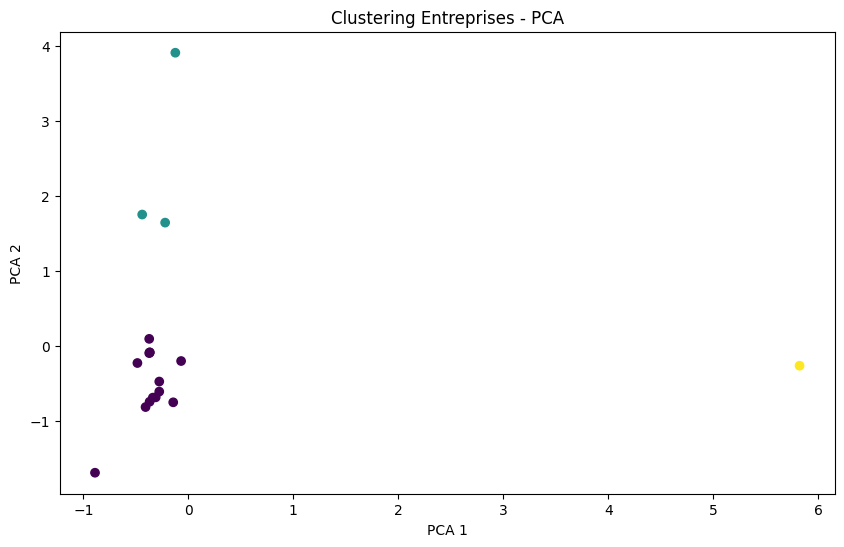

In [41]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=ml_df['cluster']
)

plt.title(
    "Clustering Entreprises - PCA"
)

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()

In [42]:
#Score de solidité

In [43]:
pivot_df['score_solidite'] = (
    (
        pivot_df['ROE'].fillna(0) * 0.3
    )
    +
    (
        pivot_df['ROA'].fillna(0) * 0.3
    )
    +
    (
        (1 - pivot_df['Debt_Ratio'].fillna(0))
        * 0.4
    )
)

In [44]:
display(
    pivot_df[
        [
            'emetteur',
            'annee',
            'score_solidite'
        ]
    ]
)

metrique,emetteur,annee,score_solidite
0,ADDOHA,2008,0.400000
1,ADDOHA,2009,0.400000
2,ADDOHA,2010,0.400000
3,ADDOHA,2013,0.400000
4,ADDOHA,2014,-0.618182
...,...,...,...
57,MAROC TELECOM,2021,3.230189
58,MAROC TELECOM,2022,3.363665
59,MAROC TELECOM,2023,0.414024
60,MAROC TELECOM,2024,0.400070


# Optimisation (OR Engine)

In [45]:
# Importation des bibliothèques

In [46]:
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.optimize import minimize

In [47]:
#Connexion SQLite
conn = sqlite3.connect(
    "finance_maroc_pro.db"
)

In [48]:
df = pd.read_sql(
    "SELECT * FROM financial_data;",
    conn
)

display(df.head())

,id,emetteur,annee,type_doc,metrique,valeur_brute,valeur_normalisee,unite_detectee,source_method,score_confiance,date_extraction
0,1,AFRIQUIA GAZ,2025,Semestriel,actif_total,9.0,9000000.0,MDH,NATIVE,0.9,2025-12-30 21:36:50
1,2,AFRIQUIA GAZ,2025,Semestriel,capitaux_propres,3.0,3000000.0,MDH,NATIVE,0.9,2025-12-30 21:36:50
2,3,AFRIQUIA GAZ,2025,Semestriel,endettement,600.0,600000000.0,MDH,NATIVE,0.9,2025-12-30 21:36:50
3,4,AFRIQUIA GAZ,2025,Semestriel,resultat_net,2.0,2000000.0,MDH,NATIVE,0.9,2025-12-30 21:36:50
4,5,AFRIQUIA GAZ,2025,Semestriel,dividendes,769.0,769000000.0,MDH,NATIVE,0.9,2025-12-30 21:36:50


In [49]:
pivot_df = df.pivot_table(
    index=['emetteur', 'annee'],
    columns='metrique',
    values='valeur_normalisee',
    aggfunc='first'
).reset_index()

display(pivot_df.head())

metrique,emetteur,annee,,actif_total,autres,aux_prises_de_participation_suivantes,capitaux_propres,cash_flow,cid,de,...,i_e_s_an_sue_tr_m_pe_e_pron_rifit_s_te,le,nantissement,que,res_courantes,res_non_courantes,resultat_net,sente_comme_suit,w,warrant
0,ADDOHA,2008,4.0,NaN,NaN,NaN,NaN,NaN,129.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ADDOHA,2009,NaN,NaN,5.0,NaN,6.0,NaN,NaN,NaN,...,NaN,NaN,3.0,2.0,NaN,NaN,NaN,NaN,NaN,4.0
2,ADDOHA,2010,NaN,NaN,NaN,NaN,NaN,NaN,53.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ADDOHA,2013,NaN,NaN,NaN,NaN,NaN,NaN,146.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ADDOHA,2014,NaN,1000000.0,NaN,NaN,11000000.0,4000000.0,33.0,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,3000000.0,NaN,NaN,NaN


In [50]:
# Calcul rendement estimé

In [51]:
pivot_df['ROE'] = (
    pivot_df['resultat_net']
    / pivot_df['capitaux_propres']
)

In [52]:
# Calcul risque estimé
pivot_df['Debt_Ratio'] = (
    pivot_df['endettement']
    / pivot_df['actif_total']
)

In [53]:
# Nettoyage données

In [54]:
portfolio_df = pivot_df[
    [
        'emetteur',
        'ROE',
        'Debt_Ratio'
    ]
].replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

display(portfolio_df)

metrique,emetteur,ROE,Debt_Ratio
4,ADDOHA,0.272727,5.000000e+00
5,ADDOHA,79.909091,4.000000e+00
6,ADDOHA,0.300000,1.000000e+00
7,ADDOHA,40.900000,3.750000e+08
8,ADDOHA,33.600000,5.000000e+08
9,ADDOHA,-0.067889,1.000000e+00
10,ADDOHA,-0.008150,1.000000e+00
11,ADDOHA,0.000095,9.720000e+02
12,ADDOHA,0.032967,3.000000e+00
13,ADDOHA,0.377778,3.000000e+00


In [55]:
portfolio_df = portfolio_df.groupby(
    'emetteur'
).mean().reset_index()

display(portfolio_df)

metrique,emetteur,ROE,Debt_Ratio
0,ADDOHA,15.531662,8.750010e+07
1,AFRIQUIA GAZ,53.573533,4.877602e+01
2,ATTIJARIWAFA BANK,44.168925,7.490620e-02
3,COSUMAR,135.015476,8.330842e+00
4,MAROC TELECOM,-1.214286,-1.715847e-01


In [57]:
# Création variables portefeuille
returns = portfolio_df['ROE'].values

risks = portfolio_df['Debt_Ratio'].values

companies = portfolio_df['emetteur'].values

n_assets = len(companies)

In [58]:
# Matrice covariance

In [59]:
cov_matrix = np.diag(risks)

# Fonction rendement portefeuille

In [60]:
def portfolio_return(weights):

    return np.sum(
        returns * weights
    )

# Fonction risque portefeuille

In [61]:
def portfolio_risk(weights):

    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

# Fonction objectif Markowitz

In [62]:
def objective(weights):

    risk = portfolio_risk(weights)

    ret = portfolio_return(weights)

    return -(ret - 0.5 * risk)

In [63]:
constraints = [

    {
        'type': 'eq',
        'fun': lambda w: np.sum(w) - 1
    }

]

In [64]:
bounds = tuple(

    (0, 0.15)

    for asset in range(n_assets)
)

In [65]:
initial_weights = np.array(

    n_assets * [1 / n_assets]

)

In [66]:
# Optimisation portefeuille avec SciPy

In [67]:
optimal = minimize(

    objective,

    initial_weights,

    method='SLSQP',

    bounds=bounds,

    constraints=constraints
)

# Résultat portefeuille optimal

In [74]:
optimal_weights = optimal.x

portfolio_result = pd.DataFrame({

    'Entreprise': companies,

    'Poids_Optimal': optimal_weights

})

display(portfolio_result)

,Entreprise,Poids_Optimal
0,ADDOHA,0.15
1,AFRIQUIA GAZ,0.15
2,ATTIJARIWAFA BANK,0.15
3,COSUMAR,0.15
4,MAROC TELECOM,0.15


In [75]:
opt_return = portfolio_return(
    optimal_weights
)

opt_risk = portfolio_risk(
    optimal_weights
)

print("\n Rendement optimal :")

print(opt_return)

print("\n Risque optimal :")

print(opt_risk)


 Rendement optimal :
37.06129644718444

 Risque optimal :
1403.1227709039053


In [76]:
portfolio_returns = []

portfolio_risks = []

for i in range(500):

    weights = np.random.random(
        n_assets
    )

    weights /= np.sum(weights)

    ret = portfolio_return(weights)

    risk = portfolio_risk(weights)

    portfolio_returns.append(ret)

    portfolio_risks.append(risk)

# Affichage frontière efficiente

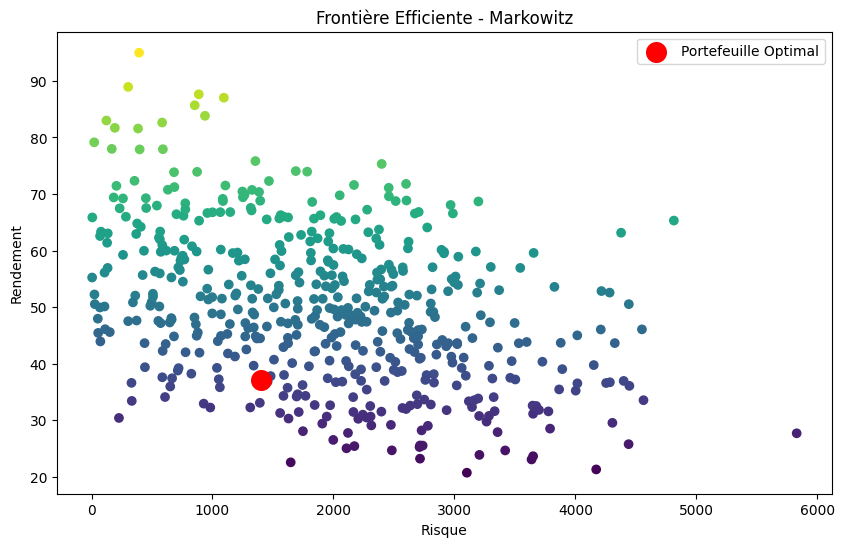

In [77]:
plt.figure(figsize=(10,6))

plt.scatter(

    portfolio_risks,

    portfolio_returns,

    c=portfolio_returns,

    cmap='viridis'
)

# Portefeuille optimal

plt.scatter(

    opt_risk,

    opt_return,

    color='red',

    s=200,

    label='Portefeuille Optimal'
)

plt.xlabel("Risque")

plt.ylabel("Rendement")

plt.title(
    "Frontière Efficiente - Markowitz"
)

plt.legend()

plt.show()

# IA Agent Collaboratif (LLM)

In [78]:
# les bibliothètiques

In [85]:
pip uninstall langchain langchain-community langchain-core langchain-openai -y

Found existing installation: langchain-community 0.4.1Note: you may need to restart the kernel to use updated packages.

Uninstalling langchain-community-0.4.1:
  Successfully uninstalled langchain-community-0.4.1
Found existing installation: langchain-core 1.4.0
Uninstalling langchain-core-1.4.0:
  Successfully uninstalled langchain-core-1.4.0
Found existing installation: langchain-openai 1.2.1
Uninstalling langchain-openai-1.2.1:
  Successfully uninstalled langchain-openai-1.2.1


In [86]:
pip install langchain-openai langchain-core langchain-community

  Using cached langchain_openai-1.2.1-py3-none-any.whl.metadata (3.1 kB)
  Using cached langchain_core-1.4.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
Using cached langchain_openai-1.2.1-py3-none-any.whl (98 kB)
Using cached langchain_core-1.4.0-py3-none-any.whl (548 kB)
Using cached langchain_community-0.4.1-py3-none-any.whl (2.5 MB)

   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   ---------------------------------------- 0/3 [langchain-core]
   -----

In [82]:
pip install langchain-groq


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [84]:
!python.exe -m pip install --upgrade pip


 MENU
 Résumé entreprise
Comparaison deux années + graphique
Analyse multi-entreprises + graphiques



Votre choix (1/2/3) :  2
Nom de l’entreprise :  ADDOHA
Année 1 :  2019
Année 2 :  2023



 Génération graphique...

📊 Données comparaison :


annee,2019,2023
metrique,,
capitaux_propres,1.000000e+07,3.024857e+09
endettement,7.500000e+08,1.000000e+06
resultat_net,4.753922e+13,9.605985e+12


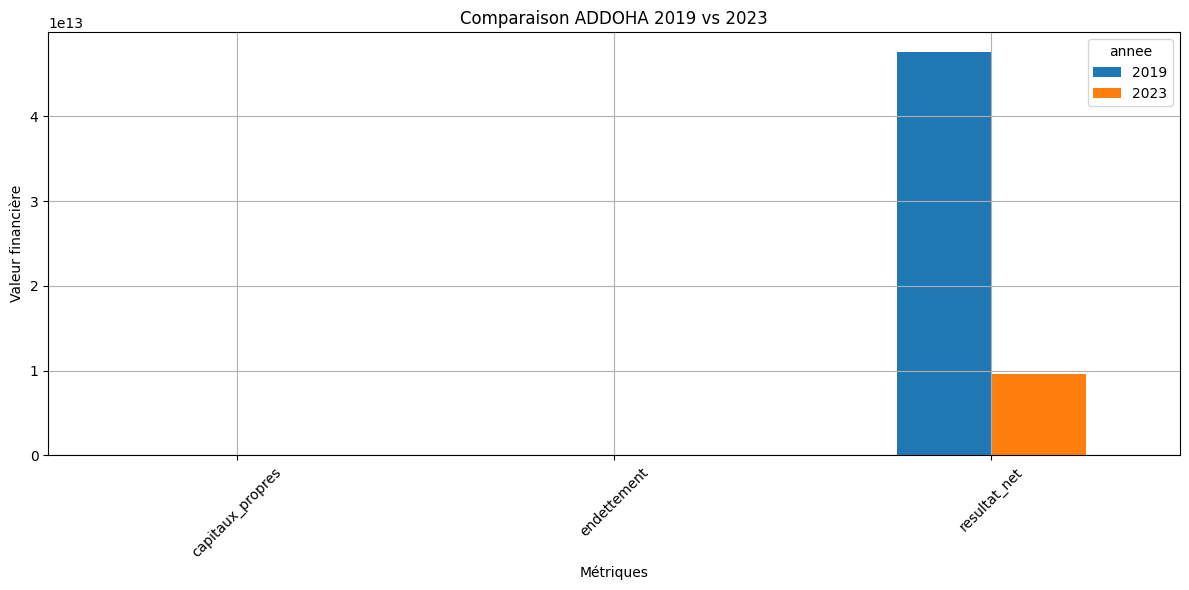


================= RAPPORT =================

**Analyse financière de l'entreprise ADDOHA entre 2019 et 2023**

**Introduction**

L'analyse financière de l'entreprise ADDOHA entre 2019 et 2023 vise à comparer les performances de l'entreprise au cours de ces deux années et à identifier les améliorations ou dégradations constatées. Les données fournies concernent les capitaux propres, le résultat net et l'endettement de l'entreprise.

**Comparaison des années**

Les données fournies sont les suivantes :

* 2019 :
 + Capitaux propres : 1,00E+07
 + Endettement : 7,50E+08
 + Résultat net : 4,09E+08
* 2023 :
 + Capitaux propres : 1,0582E+10 (valeur normalisée) et 2,00E+06 (valeur non normalisée)
 + Endettement : 1,00E+06
 + Résultat net : 1,00E+06 (valeur normalisée) et 1,4785E+13 (valeur non normalisée)

**Analyse de la rentabilité**

La rentabilité de l'entreprise peut être évaluée en analysant le résultat net. En 2019, le résultat net était de 4,09E+08, tandis qu'en 2023, il était de 1,00

 n


In [92]:
# ======================================================
#               IMPORTS
# ======================================================

import logging

# ======================================================
# MASQUER LES LOGS HTTPX
# ======================================================

logging.getLogger("httpx").setLevel(
    logging.WARNING
)

# ======================================================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

from langchain_groq import ChatGroq

from langchain_core.prompts import (
    ChatPromptTemplate
)

from langchain_core.output_parsers import (
    StrOutputParser
)

# ======================================================
#               AGENT IA COLLABORATIF
# ======================================================

class AgentIACollaboratif:

    def __init__(
        self,
        api_key,
        db_path="finance_maroc_pro.db"
    ):

        self.db_path = db_path

        self.llm = ChatGroq(

            model_name="llama-3.3-70b-versatile",

            groq_api_key=api_key,

            temperature=0
        )

        self.output_parser = StrOutputParser()

    # ==================================================
    # DATA SQL
    # ==================================================

    def _get_data(
        self,
        query,
        params=None
    ):

        try:

            conn = sqlite3.connect(
                self.db_path
            )

            df = pd.read_sql_query(

                query,

                conn,

                params=params
            )

            conn.close()

            return df

        except Exception as e:

            print("❌ Erreur SQL :", e)

            return pd.DataFrame()

    # ==================================================
    # REDUCTION DATA
    # ==================================================

    def _reduce_data(
        self,
        df,
        max_rows=25
    ):

        return df.head(max_rows)

    # ==================================================
    # NETTOYAGE DONNEES IA
    # ==================================================

    def _clean_financial_data(
        self,
        df
    ):

        df = df.dropna(
            subset=["valeur_normalisee"]
        )

        df = df[
            df["valeur_normalisee"] > 1000
        ]

        df = df[
            df["valeur_normalisee"] < 1e15
        ]

        return df

    # ==================================================
    # RESUME ENTREPRISE
    # ==================================================

    def resume_entreprise(
        self,
        entreprise
    ):

        query = """
        SELECT annee,
               metrique,
               valeur_normalisee
        FROM financial_data
        WHERE emetteur LIKE ?
        """

        data = self._get_data(

            query,

            (f"%{entreprise}%",)
        )

        data = self._clean_financial_data(
            data
        )

        if data.empty:

            return (
                "❌ Aucune donnée "
                "financière exploitable."
            )

        data = self._reduce_data(data)

        prompt = ChatPromptTemplate.from_template("""

Tu es un analyste financier expert.

Résumé financier de l’entreprise {ent} :

{data}

Instructions :
- Analyse professionnelle
- Identifier évolution financière
- Identifier risques
- Identifier points forts
- Conclure clairement
- Réponse structurée

""")

        return (

            prompt

            | self.llm

            | self.output_parser

        ).invoke({

            "ent": entreprise,

            "data": data.to_string(
                index=False
            )
        })

    # ==================================================
    # COMPARAISON ENTREPRISE
    # ==================================================

    def comparaison(
        self,
        entreprise,
        an1,
        an2
    ):

        query = """
        SELECT annee,
               metrique,
               valeur_normalisee
        FROM financial_data
        WHERE emetteur LIKE ?
        AND annee IN (?, ?)
        """

        data = self._get_data(

            query,

            (
                f"%{entreprise}%",

                an1,

                an2
            )
        )

        data = self._clean_financial_data(
            data
        )

        if data.empty:

            return (
                "❌ Aucune donnée "
                "financière exploitable."
            )

        data = self._reduce_data(data)

        prompt = ChatPromptTemplate.from_template("""

Tu es un analyste financier expert.

Compare l’entreprise {ent}
entre {a1} et {a2}.

Données :

{data}

Instructions :
- Comparer les années
- Identifier amélioration/dégradation
- Analyser rentabilité
- Analyser endettement
- Fournir conclusion claire

""")

        return (

            prompt

            | self.llm

            | self.output_parser

        ).invoke({

            "ent": entreprise,

            "a1": an1,

            "a2": an2,

            "data": data.to_string(
                index=False
            )
        })

    # ==================================================
    # GRAPHIQUE COMPARAISON
    # ==================================================

    def plot_comparaison(
        self,
        entreprise,
        an1,
        an2
    ):

        query = """
        SELECT annee,
               metrique,
               valeur_normalisee
        FROM financial_data
        WHERE emetteur LIKE ?
        AND annee IN (?, ?)
        """

        df = self._get_data(

            query,

            (
                f"%{entreprise}%",

                an1,

                an2
            )
        )

        df = self._clean_financial_data(
            df
        )

        if df.empty:

            print(
                "❌ Aucune donnée graphique."
            )

            return

        # ==============================================
        # PIVOT
        # ==============================================

        pivot = df.pivot_table(

            index="metrique",

            columns="annee",

            values="valeur_normalisee",

            aggfunc="mean"
        )

        print("\n📊 Données comparaison :")

        display(pivot)

        # ==============================================
        # GRAPHIQUE BARRES
        # ==============================================

        pivot.plot(

            kind="bar",

            figsize=(12,6)
        )

        plt.title(
            f"Comparaison {entreprise} "
            f"{an1} vs {an2}"
        )

        plt.ylabel(
            "Valeur financière"
        )

        plt.xlabel("Métriques")

        plt.xticks(rotation=45)

        plt.grid(True)

        plt.tight_layout()

        plt.show()

    # ==================================================
    # MULTI ENTREPRISES
    # ==================================================

    def multi_entreprises(
        self,
        entreprises,
        annees
    ):

        ent_conditions = " OR ".join(

            ["emetteur LIKE ?"]

            * len(entreprises)
        )

        an_placeholders = ",".join(

            ["?"]

            * len(annees)
        )

        query = f"""
        SELECT emetteur,
               annee,
               metrique,
               valeur_normalisee
        FROM financial_data
        WHERE annee IN ({an_placeholders})
        AND ({ent_conditions})
        """

        params = (

            annees

            + [
                f"%{e}%"

                for e in entreprises
            ]
        )

        data = self._get_data(

            query,

            params
        )

        data = self._clean_financial_data(
            data
        )

        if data.empty:

            return (
                "❌ Aucune donnée "
                "financière exploitable."
            )

        data = self._reduce_data(data)

        prompt = ChatPromptTemplate.from_template("""

Tu es un analyste financier senior.

Analyse comparative multi-entreprises :

{data}

Instructions :
- Comparer entreprises
- Identifier meilleure performance
- Identifier entreprise risquée
- Identifier tendances
- Faire synthèse finale

""")

        return (

            prompt

            | self.llm

            | self.output_parser

        ).invoke({

            "data": data.to_string(
                index=False
            )
        })

    # ==================================================
    # GRAPHIQUES MULTI ENTREPRISES
    # ==================================================

    def plot_multi_entreprises(
        self,
        entreprises,
        annees
    ):

        ent_conditions = " OR ".join(

            ["emetteur LIKE ?"]

            * len(entreprises)
        )

        an_placeholders = ",".join(

            ["?"]

            * len(annees)
        )

        query = f"""
        SELECT emetteur,
               annee,
               valeur_normalisee
        FROM financial_data
        WHERE annee IN ({an_placeholders})
        AND ({ent_conditions})
        """

        params = (

            annees

            + [
                f"%{e}%"

                for e in entreprises
            ]
        )

        df = self._get_data(

            query,

            params
        )

        df = self._clean_financial_data(
            df
        )

        if df.empty:

            print(
                "❌ Pas de données "
                "pour graphique."
            )

            return

        # ==============================================
        # MOYENNE PAR ENTREPRISE
        # ==============================================

        df_grouped = (

            df.groupby(
                ["emetteur", "annee"],
                as_index=False
            )["valeur_normalisee"]

            .mean()
        )

        print("\n📊 Données graphique :")

        print(df_grouped)

        plt.figure(figsize=(10, 5))

        for ent in df_grouped[
            "emetteur"
        ].unique():

            sub = df_grouped[
                df_grouped["emetteur"] == ent
            ]

            if len(sub) == 1:

                plt.scatter(

                    sub["annee"],

                    sub["valeur_normalisee"],

                    s=100,

                    label=ent
                )

            else:

                plt.plot(

                    sub["annee"],

                    sub["valeur_normalisee"],

                    marker="o",

                    linewidth=2,

                    label=ent
                )

        plt.xlabel("Année")

        plt.ylabel(
            "Valeur normalisée moyenne"
        )

        plt.title(
            "Évolution financière des entreprises"
        )

        plt.xticks(

            sorted(
                df_grouped["annee"].unique()
            )
        )

        plt.legend()

        plt.grid(True)

        plt.tight_layout()

        plt.show()

    # ==================================================
    # SAUVEGARDE RAPPORT
    # ==================================================

    def sauvegarder_rapport(
        self,
        contenu,
        titre="Rapport"
    ):

        nom = (

            f"{titre}_"

            f"{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
        )

        with open(

            nom,

            "w",

            encoding="utf-8"
        ) as f:

            f.write(contenu)

        return (
            f" Rapport sauvegardé : {nom}"
        )

# ======================================================
#                   MENU UTILISATEUR
# ======================================================

if __name__ == "__main__":

    # ==================================================
    # CLE API GROQ
    # ==================================================

    MY_GROQ_KEY = "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"

    agent = AgentIACollaboratif(
        MY_GROQ_KEY
    )

    print("\n MENU")

    print(" Résumé entreprise")

    print("Comparaison deux années + graphique")

    print(
        "Analyse multi-entreprises + graphiques"
    )

    choix = input(
        "\nVotre choix (1/2/3) : "
    ).strip()

    try:

        # ==============================================
        # RESUME
        # ==============================================

        if choix == "1":

            ent = input(
                "Nom de l’entreprise : "
            ).strip()

            resultat = (
                agent.resume_entreprise(ent)
            )

        # ==============================================
        # COMPARAISON
        # ==============================================

        elif choix == "2":

            ent = input(
                "Nom de l’entreprise : "
            ).strip()

            a1 = int(
                input("Année 1 : ")
            )

            a2 = int(
                input("Année 2 : ")
            )

            resultat = agent.comparaison(

                ent,

                a1,

                a2
            )

            print(
                "\n Génération graphique..."
            )

            agent.plot_comparaison(

                ent,

                a1,

                a2
            )

        # ==============================================
        # MULTI ENTREPRISES
        # ==============================================

        elif choix == "3":

            ents = input(
                "Entreprises (séparées par virgule) : "
            )

            annees_input = input(
                "Années (séparées par virgule) : "
            )

            entreprises = [

                e.strip()

                for e in ents.split(",")
            ]

            annees = [

                int(a.strip())

                for a in annees_input.split(",")
            ]

            resultat = (
                agent.multi_entreprises(

                    entreprises,

                    annees
                )
            )

            print(
                "\n Génération graphiques..."
            )

            agent.plot_multi_entreprises(

                entreprises,

                annees
            )

        # ==============================================
        # CHOIX INVALIDE
        # ==============================================

        else:

            resultat = " Choix invalide."

    except ValueError:

        resultat = (
            " Erreur années invalides."
        )

    # ==================================================
    # RAPPORT FINAL
    # ======================================================

    print(
        "\n================= RAPPORT =================\n"
    )

    print(resultat)

    # ==================================================
    # SAUVEGARDE
    # ======================================================

    print("\n Sauvegarder rapport ? (o/n)")

    if input().lower() == "o":

        print(

            agent.sauvegarder_rapport(
                resultat
            )
        )

In [93]:
pip install streamlit